# Parte 1: Tokenization

In [1]:
%pip install nltk -q

Note: you may need to restart the kernel to use updated packages.


## Tokenization: Stemming

In [1]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("spanish")
#palabras = ["jugando", "jugador", "jugaría"]
palabras = ["jugando", "jugar", "jugaría"]

for palabra in palabras:
    print(f"{palabra} -> {stemmer.stem(palabra)}")


jugando -> jug
jugar -> jug
jugaría -> jug


## Tokenization: Lemmatization

In [1]:
%pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [3]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ------------------------------ --------- 9.7/12.9 MB 48.0 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 44.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [4]:
# Lemmatization

import numpy as np
import spacy

nlp = spacy.load("es_core_news_sm")

# Texto de ejemplo
texto = "jugando, jugar, jugaría"

# Aplicar lematización
doc = nlp(texto)

for token in doc:
    print(f"{token.text} -> {token.lemma_}")



jugando -> jugar
, -> ,
jugar -> jugar
, -> ,
jugaría -> jugar


- Hoy en los proyectos reales utilizamos tokenizadores más avanzados como **tiktoken** de OpenAI.

# Parte 2: Embeddings

## Embeddings con Bag of Words

In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 53.6 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------------- -------------------------- 12.1/36.6 MB 68.2 MB/s eta 0:00:01
   ------------------------ --------------- 22.8/36.6 MB 56.5 MB/s eta 0:00:01
   ------------------------------------ --- 33.6/36.6 MB 56.0 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 47.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -----------

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

documentos = [
    "Tomo café cada día, me encanta el café",
    "Futbol nació en UK, me encanta el futbol",
    "Ciclismo es divertido, me encanta el ciclismo"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documentos)

# Corpus (ordenado alfabéticamente)
palabras = vectorizer.get_feature_names_out()

# Matriz BoW
matriz = X.toarray()

# Mostrar el Corpus generado
print("Corpus:\n", palabras)

# Mostrar las representaciones vectoriales de los documentos
print("\nRepresentación BoW de los documentos:")
print(matriz)
print()

# Para cada documento, encontrar la palabra más frecuente
for i, conteos in enumerate(matriz):
    indice_max = conteos.argmax()
    palabra_mas_representativa = palabras[indice_max]
    print(f"Documento {i+1}: palabra más representativa -> '{palabra_mas_representativa}' (frecuencia: {conteos[indice_max]})")


Corpus:
 ['cada' 'café' 'ciclismo' 'divertido' 'día' 'el' 'en' 'encanta' 'es'
 'futbol' 'me' 'nació' 'tomo' 'uk']

Representación BoW de los documentos:
[[1 2 0 0 1 1 0 1 0 0 1 0 1 0]
 [0 0 0 0 0 1 1 1 0 2 1 1 0 1]
 [0 0 2 1 0 1 0 1 1 0 1 0 0 0]]

Documento 1: palabra más representativa -> 'café' (frecuencia: 2)
Documento 2: palabra más representativa -> 'futbol' (frecuencia: 2)
Documento 3: palabra más representativa -> 'ciclismo' (frecuencia: 2)


## Embeddings con TF-IDF

## ¿Para qué sirve TF-IDF?

TF-IDF mide cuán importante es una palabra en un documento, pero considerando también en cuántos documentos aparece. Esto resuelve un problema del Bag of Words puro: palabras muy frecuentes (como “el”, “de”) aparecen mucho, pero no aportan significado diferenciador.

TF-IDF le da un peso más alto a las palabras que:

- aparecen con frecuencia dentro de un documento (TF alto)

- pero aparecen en pocos documentos (IDF alto)

En otras palabras:

- Si una palabra aparece mucho en un solo documento, pero no en todos, se considera representativa de ese documento.

- Si aparece en todos los documentos, se penaliza su peso, porque no discrimina nada.

## Fórmulas simplificadas
### TF (Term Frequency)
Es la proporción de veces que aparece el término en el documento:


$$TF(t, d) = \frac{\text{número de veces que el término } t \text{ aparece en } d}{\text{total de términos en } d}$$


### IDF (Inverse Document Frequency)
Inversamente proporcional a la cantidad de documentos donde aparece el término:

$$IDF(t) = \log \left( \frac{N}{1 + n_t} \right)$$

donde:  
- \( N \) = número total de documentos  
- \( n_t \) = número de documentos que contienen el término \( t \)

### TF-IDF
Multiplica ambos:

$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

### Intuición sencilla
Palabra común (p.ej. “el”): TF alto, pero IDF bajo → TF-IDF bajo

Palabra relevante (p.ej. “inflación” en un texto económico): TF alto, IDF alto → TF-IDF alto

### Por qué se usa tanto en NLP?
Porque:

- transforma texto a vectores numéricos

- preserva cierta noción de relevancia

- es sencillo y eficiente

- sirve muy bien como entrada para algoritmos de clasificación (Naive Bayes, SVM, etc.)

De hecho, en pipelines de clasificación de textos, TF-IDF casi siempre supera a Bag of Words puro porque filtra automáticamente palabras poco informativas.

In [13]:
# import numpy as np
# np.log(2700/10)*20

## 1.1- TF-IDF - Ejemplo 1

D1: el precio de la vivienda sube
D2: la inflación sube
D3: el mercado observa la inflación

TF-IDF:

   inflación   mercado   observa    precio      sube  vivienda
0   0.000000  0.000000  0.000000  0.622766  0.473630  0.622766
1   0.707107  0.000000  0.000000  0.000000  0.707107  0.000000
2   0.473630  0.622766  0.622766  0.000000  0.000000  0.000000


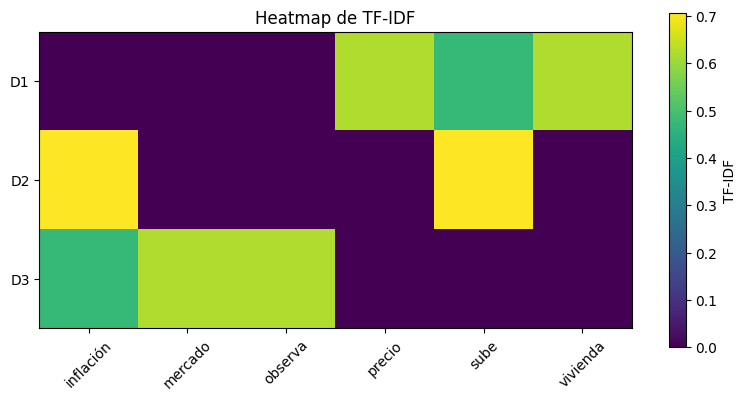

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Corpus de ejemplo
corpus = [
    "el precio de la vivienda sube", # precio vivienda sube
    "la inflación sube",
    "el mercado observa la inflación"
]

# Stopwords en español (se puede usar nltk)
stopwords_es = [
    "el", "la", "de"
]

# Crear el vectorizador con stopwords personalizadas
vectorizer = TfidfVectorizer(stop_words=stopwords_es)

# Ajustar y transformar
X = vectorizer.fit_transform(corpus)

# Obtener términos
terms = vectorizer.get_feature_names_out()

# Mostrar el Corpus
i = 1
for t in corpus:
  print(f"D{i}: {t}")
  i += 1

# Pasar a DataFrame
df = pd.DataFrame(X.toarray(), columns=terms)
print("\nTF-IDF:\n")
print(df)

# Graficar como heatmap
plt.figure(figsize=(8, 4))
plt.imshow(df, cmap="viridis")
plt.xticks(range(len(terms)), terms, rotation=45)
plt.yticks(range(len(corpus)), [f"D{i+1}" for i in range(len(corpus))])
plt.colorbar(label="TF-IDF")
plt.title("Heatmap de TF-IDF")
plt.tight_layout()
plt.show()


## Caso: Plagio de Tesis + Similitud del coseno

Matriz de similitudes (coseno) con 4 decimales:
         Tesis 1  Tesis 2  Tesis 3
Tesis 1   1.0000   0.3023   0.7063
Tesis 2   0.3023   1.0000   0.2693
Tesis 3   0.7063   0.2693   1.0000

Se presume un plagio entre la tesis 1 y la tesis 3.


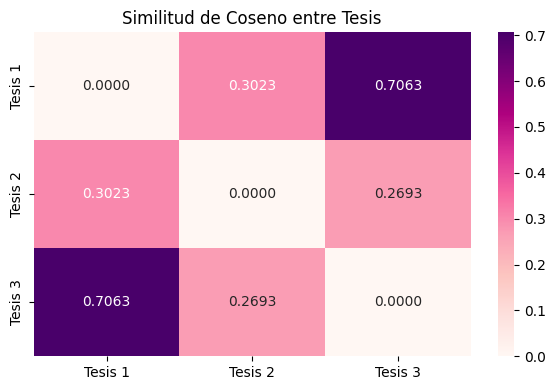


Se presume un plagio entre la tesis 1 y la tesis 3.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Documentos simulados
tesis_1 = """
El procesamiento del lenguaje natural (NLP) es un subcampo de la inteligencia artificial
que permite a las máquinas entender, interpretar y generar texto en lenguaje humano.
Entre las aplicaciones de NLP están la traducción automática, el análisis de sentimientos
y los chatbots.
"""

tesis_2 = """
La clasificación de textos es una de las tareas fundamentales en el procesamiento del lenguaje natural.
Implica categorizar automáticamente documentos en diferentes clases usando algoritmos
como Naive Bayes, SVM o redes neuronales. Su aplicación incluye filtrado de spam y análisis de opiniones.
"""

tesis_3 = """
El procesamiento del lenguaje natural (NLP) es un campo clave de la inteligencia artificial
que ayuda a las máquinas a comprender y generar texto en lenguaje humano.
Aplicaciones importantes incluyen la traducción automática, chatbots y análisis de sentimientos.
"""

# Vectorizador TF-IDF
vectorizer = TfidfVectorizer()
documents = [tesis_1, tesis_2, tesis_3]
tfidf_matrix = vectorizer.fit_transform(documents)

# Similitud del coseno
similarities = cosine_similarity(tfidf_matrix)

# Mostrar matriz con formato
df_sim = pd.DataFrame(similarities,
                      index=["Tesis 1", "Tesis 2", "Tesis 3"],
                      columns=["Tesis 1", "Tesis 2", "Tesis 3"])
print("Matriz de similitudes (coseno) con 4 decimales:")
print(df_sim.round(4))

# Detectar posible plagio
np.fill_diagonal(similarities, 0)
most_similar_docs = np.unravel_index(similarities.argmax(), similarities.shape)
print(f"\nSe presume un plagio entre la tesis {most_similar_docs[0]+1} y la tesis {most_similar_docs[1]+1}.")

import seaborn as sns
import matplotlib.pyplot as plt


# Dibujar heatmap
plt.figure(figsize=(6, 4))
#sns.heatmap(df_sim, annot=True, cmap="RdPu", fmt=".4f", cbar=True, square=True)
sns.heatmap(df_sim, annot=True, cmap="RdPu", fmt=".4f", cbar=True, square=False)

plt.title("Similitud de Coseno entre Tesis")
plt.tight_layout()
plt.show()


# Detectar plagio
np.fill_diagonal(similarities, 0)
most_similar_docs = np.unravel_index(similarities.argmax(), similarities.shape)
print(f"\nSe presume un plagio entre la tesis {most_similar_docs[0]+1} y la tesis {most_similar_docs[1]+1}.")

